# EDA 03 — Target Relationships, Transformations and Encodings

Third step of the EDA stage. Ranks every predictor by its association with default
(Spearman correlation and Information Value), then chooses a transformation per
heavy-tailed feature and studies the two ordinal encodings (utilisation bands, age
life-stages) used by feature configuration B in the Fitting stage.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [2]:
# Paths and column rename map (same convention as EDA 01).
DATA_PATH = "../data/cs-training.csv"
RENAME = {
    "SeriousDlqin2yrs": "target",
    "RevolvingUtilizationOfUnsecuredLines": "revolving_utilisation",
    "age": "age",
    "NumberOfTime30-59DaysPastDueNotWorse": "past_due_30_59",
    "DebtRatio": "debt_ratio",
    "MonthlyIncome": "monthly_income",
    "NumberOfOpenCreditLinesAndLoans": "open_credit_lines_and_loans",
    "NumberOfTimes90DaysLate": "past_due_90",
    "NumberRealEstateLoansOrLines": "real_estate_loans_or_lines",
    "NumberOfTime60-89DaysPastDueNotWorse": "past_due_60_89",
    "NumberOfDependents": "dependents",
}

In [3]:
# Load, rename and recode sentinels to legitimate-maximum + 1 (exploration-only recode,
# as in EDA 02) so that 96/98 do not act as artificial outliers in the rankings below.
df = pd.read_csv(DATA_PATH, index_col=0).rename(columns=RENAME)
for col in ["past_due_30_59", "past_due_60_89", "past_due_90"]:
    legit_max = df.loc[~df[col].isin([96, 98]), col].max()
    df[col] = df[col].replace({96: legit_max + 1, 98: legit_max + 1})
y = df["target"]
print(f"rows: {len(df):,}")

rows: 150,000


In [4]:
# Information Value: bins a feature into (up to) 10 quantile bins and sums the
# weight-of-evidence contribution of each bin. Conventional reading: < 0.02 useless,
# 0.02-0.1 weak, 0.1-0.3 medium, > 0.3 strong. Discrete features with few distinct values
# are binned by their values directly. Zero-inflated counters (e.g. past_due_90: ~95%
# zeros yet 18 distinct values) are a special case: every decile edge equals zero, so a
# plain quantile cut collapses into one bin and silently reports IV = 0 for some of the
# strongest predictors. When that happens, zero gets its own bin and the positive values
# are quantile-binned separately.
def information_value(feature, target, n_bins=10):
    data = pd.DataFrame({"x": feature, "y": target}).dropna()
    if data["x"].nunique() <= n_bins:
        data["bin"] = data["x"]
    else:
        data["bin"] = pd.qcut(data["x"], n_bins, duplicates="drop")
        if data["bin"].nunique() < 2:  # quantile cut collapsed: zero-inflated feature
            positive = data["x"] > 0
            n_pos_bins = min(n_bins - 1, int(data.loc[positive, "x"].nunique()))
            data["bin"] = "zero"
            data.loc[positive, "bin"] = pd.qcut(data.loc[positive, "x"], n_pos_bins,
                                                duplicates="drop").astype(str)
    iv = 0.0
    n_pos, n_neg = (data["y"] == 1).sum(), (data["y"] == 0).sum()
    for _, grp in data.groupby("bin", observed=True):
        pos = ((grp["y"] == 1).sum() + 0.5) / n_pos
        neg = ((grp["y"] == 0).sum() + 0.5) / n_neg
        iv += (pos - neg) * np.log(pos / neg)
    return iv

In [5]:
# Association ranking of the ten predictors. The past-due counters dominate the rank
# correlation (Spearman ~0.26-0.34) and sit right behind revolving utilisation on IV
# (0.87 / 0.59 / 0.47 vs 1.11); income and debt ratio are weak on their own. This
# ranking guides which features deserve engineered derivatives in EDA 04.
features = [c for c in df.columns if c != "target"]
rows = []
for col in features:
    valid = df[col].notna()
    rho = spearmanr(df.loc[valid, col], y[valid]).statistic
    rows.append({"feature": col, "spearman": rho,
                 "IV": information_value(df[col], y)})
assoc = pd.DataFrame(rows).sort_values("IV", ascending=False).reset_index(drop=True)
assoc.round(4)

,feature,spearman,IV
0,revolving_utilisation,0.2404,1.1124
1,past_due_90,0.3423,0.8660
2,past_due_60_89,0.2771,0.5870
3,past_due_30_59,0.2574,0.4719
4,age,-0.1170,0.2589
5,monthly_income,-0.0670,0.0803
6,debt_ratio,0.0206,0.0736
7,open_credit_lines_and_loans,-0.0386,0.0668
8,dependents,0.0460,0.0241
9,real_estate_loans_or_lines,-0.0341,0.0121


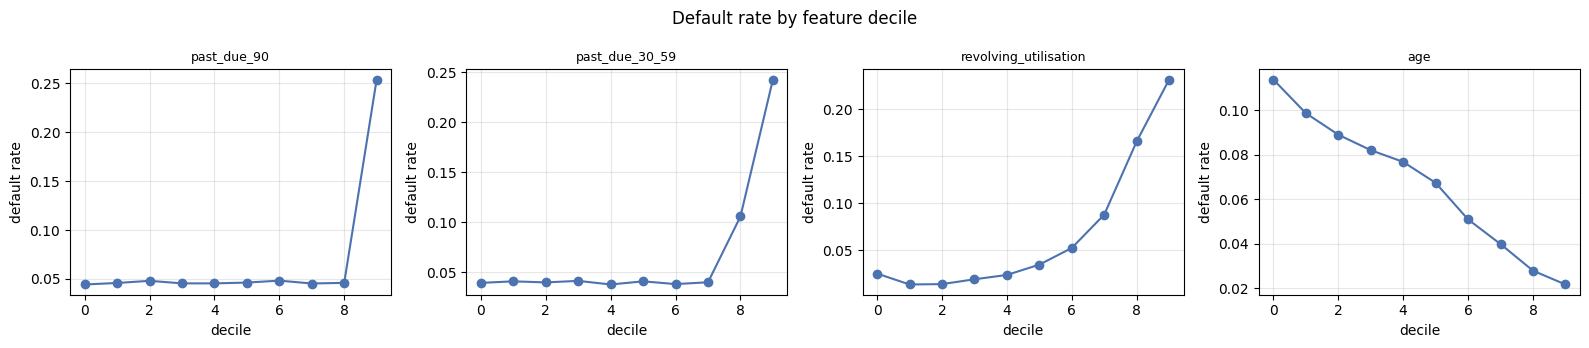

In [6]:
# Default rate by feature decile for the four strongest predictors. All four are cleanly
# monotonic, which supports simple monotone treatments (and the monotonic constraints
# given to XGBoost in Fitting 03).
top = ["past_due_90", "past_due_30_59", "revolving_utilisation", "age"]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col in zip(axes, top):
    valid = df[col].notna()
    bins = pd.qcut(df.loc[valid, col].rank(method="first"), 10, labels=False)
    dr = y[valid].groupby(bins).mean()
    ax.plot(dr.index, dr.values, marker="o", color="#4C72B0")
    ax.set_title(f"{col}", fontsize=9)
    ax.set_xlabel("decile")
    ax.set_ylabel("default rate")
    ax.grid(alpha=0.3)
fig.suptitle("Default rate by feature decile")
plt.tight_layout()
plt.show()

In [7]:
# Transformation study for the capped heavy-tailed features. Two criteria are reported per
# candidate transform, both computed on values capped at the 99th percentile (matching the
# winsorisation applied in the Fitting stage):
#   (1) residual SKEWNESS - the descriptive criterion (closer to 0 is better); and
#   (2) the LINEARITY OF THE DEFAULT LOG-ODDS against the transformed feature, summarised
#       by the R^2 of a decile-binned log-odds-vs-feature-mean fit - the property a
#       logistic regression actually relies on, and the stronger justification.
# The transform maximising the log-odds-linearity R^2 is the primary pick (skewness as the
# secondary tie-break); it is compared against the deployed transform_map below.
def logodds_linearity_r2(x, target, n_bins=10):
    d = pd.DataFrame({"x": np.asarray(x, float), "y": np.asarray(target, float)}).dropna()
    d["bin"] = pd.qcut(d["x"].rank(method="first"), n_bins, labels=False)
    g = d.groupby("bin").agg(x_mean=("x", "mean"), rate=("y", "mean"))
    g = g[(g["rate"] > 0) & (g["rate"] < 1)]            # drop degenerate (all-0 / all-1) bins
    if len(g) < 3:
        return np.nan
    logodds = np.log(g["rate"] / (1 - g["rate"]))
    return float(np.corrcoef(g["x_mean"], logodds)[0, 1] ** 2)

TRANSFORM_CANDIDATES = {"identity": lambda s: s,
                        "log1p": lambda s: np.log1p(s.clip(lower=0)),
                        "sqrt": lambda s: np.sqrt(s.clip(lower=0))}
candidates = ["revolving_utilisation", "debt_ratio", "monthly_income",
              "open_credit_lines_and_loans", "dependents"]
rows, r2_selected = [], {}
for col in candidates:
    x = df[col].clip(upper=df[col].quantile(0.99))
    r2 = {name: logodds_linearity_r2(fn(x), y) for name, fn in TRANSFORM_CANDIDATES.items()}
    xs = x.dropna()
    r2_selected[col] = max(r2, key=lambda k: (r2[k] if not np.isnan(r2[k]) else -np.inf))
    rows.append({"feature": col,
                 "skew_log1p": np.log1p(xs).skew(), "skew_sqrt": np.sqrt(xs).skew(),
                 "r2_identity": r2["identity"], "r2_log1p": r2["log1p"], "r2_sqrt": r2["sqrt"],
                 "r2_pick": r2_selected[col]})
transform_study = pd.DataFrame(rows)
transform_study.round(3)

,feature,skew_log1p,skew_sqrt,r2_identity,r2_log1p,r2_sqrt,r2_pick
0,revolving_utilisation,0.714,0.332,0.966,0.969,0.906,log1p
1,debt_ratio,1.741,2.417,0.147,0.104,0.145,identity
2,monthly_income,-4.478,0.223,0.808,0.516,0.814,sqrt
3,open_credit_lines_and_loans,-0.777,-0.156,0.110,0.380,0.259,log1p
4,dependents,0.804,0.678,0.912,0.944,0.941,log1p


In [8]:
# Reconcile the R^2-preferred transforms with the transform_map deployed by the Fitting
# stage. Acceptance is agreement; any disagreement is SURFACED, not silently applied -
# changing a transform would require re-fitting the whole pipeline (Fitting 01 -> Scoring
# 03), so it is a decision to flag for the analyst, not to automate here.
import os, json
PARAMS_PATH = "../artifacts/pipeline_params.json"
deployed = json.load(open(PARAMS_PATH))["transform_map"] if os.path.exists(PARAMS_PATH) else {}
disagree = {c: {"r2_pick": r2_selected[c], "deployed": deployed.get(c)}
            for c in candidates if deployed.get(c) and r2_selected[c] != deployed[c]}
if not deployed:
    print("pipeline_params.json not found - run Fitting 01 to enable the transform_map check.")
elif disagree:
    print("FLAG - the log-odds-linearity R^2 disagrees with the deployed transform_map; "
          "the pipeline is left UNCHANGED:")
    for c, d in disagree.items():
        print(f"  {c}: R^2 prefers '{d['r2_pick']}', deployed uses '{d['deployed']}'")
    print("  Note: the affected feature(s) are weak predictors with low log-odds-linearity")
    print("  R^2 under every transform, and the deployed choice is justified on the")
    print("  skewness criterion. Revisit only via a full pipeline re-run if desired.")
else:
    print("log-odds-linearity R^2 confirms the deployed transform_map for all candidates.")

FLAG - the log-odds-linearity R^2 disagrees with the deployed transform_map; the pipeline is left UNCHANGED:
  debt_ratio: R^2 prefers 'identity', deployed uses 'log1p'
  Note: the affected feature(s) are weak predictors with low log-odds-linearity
  R^2 under every transform, and the deployed choice is justified on the
  skewness criterion. Revisit only via a full pipeline re-run if desired.


In [9]:
# Chosen ordinal encoding for revolving utilisation: five interpretable bands. The default
# rate rises monotonically across the bands and the over-100% band (~6x lift) keeps its
# meaning, which a winsorised continuous version would destroy. Configuration B replaces
# the continuous feature with this band code.
util = df["revolving_utilisation"]
bands = pd.cut(util, bins=[-np.inf, 0.0, 0.30, 0.60, 1.00, np.inf],
               labels=["0%", "1-30%", "31-60%", "61-100%", ">100%"], include_lowest=True)
util_table = pd.DataFrame({
    "rows": bands.value_counts(sort=False),
    "default_rate": y.groupby(bands, observed=True).mean(),
})
util_table["lift_vs_baseline"] = (util_table["default_rate"] / y.mean()).round(2)
util_table.round(4)

,rows,default_rate,lift_vs_baseline
revolving_utilisation,,,
0%,10878,0.0294,0.44
1-30%,82004,0.0212,0.32
31-60%,21887,0.0668,1.00
61-100%,31910,0.1650,2.47
>100%,3321,0.3725,5.57


In [10]:
# Chosen ordinal encoding for age: three life stages (young < 40, middle 40-65,
# senior > 65) with a clean monotone decrease in default rate. Configuration B replaces
# continuous age with this code; both encodings are kept for interpretability, not for
# information gain (binning cannot create information that the raw feature lacks).
stages = pd.cut(df["age"], bins=[-np.inf, 39, 65, np.inf],
                labels=["young (<40)", "middle (40-65)", "senior (>65)"])
pd.DataFrame({
    "rows": stages.value_counts(sort=False),
    "default_rate": y.groupby(stages, observed=True).mean(),
}).round(4)

,rows,default_rate
age,,
young (<40),32004,0.1053
middle (40-65),89397,0.0667
senior (>65),28599,0.0241


## Mutual information of the ordinal encodings vs the continuous originals (DPI check)

A predecessor methodology (v4) claimed the ordinal encodings *raise* the mutual
information (MI) with the target relative to the continuous originals. That cannot be
true: binning is a deterministic function `f`, and by the **data-processing inequality**
`MI(f(X), Y) <= MI(X, Y)` — a deterministic recoding can only lose information, never
create it. The cell below estimates both MIs directly (averaged over 10 seeds, because the
kNN estimator for continuous inputs is stochastic). Any apparent `ordinal_MI > continuous_MI`
is an **estimator artefact** — the kNN MI estimator is biased low on continuous inputs —
not a real gain. The encodings are therefore retained on **interpretability and
robustness** grounds (the >100% utilisation band is a genuine categorical risk signal),
**explicitly not** for an information gain.

In [11]:
# Estimate MI for the continuous original and its ordinal encoding, for the two encoded
# features. The continuous inputs use the kNN estimator (discrete_features=False); the
# ordinal codes use the discrete estimator. Both are averaged over 10 seeds because the
# kNN estimator is stochastic.
from sklearn.feature_selection import mutual_info_classif

def mean_mi(x, target, discrete, seeds=range(10)):
    x = np.asarray(x, float).reshape(-1, 1)
    return float(np.mean([mutual_info_classif(x, target, discrete_features=[discrete],
                                              random_state=s)[0] for s in seeds]))

util_band_code = pd.cut(df["revolving_utilisation"], bins=[-np.inf, 0.0, 0.30, 0.60, 1.00, np.inf],
                        labels=[0, 1, 2, 3, 4], include_lowest=True).astype(int)
age_stage_code = pd.cut(df["age"], bins=[-np.inf, 39, 65, np.inf],
                        labels=[0, 1, 2], include_lowest=True).astype(int)

mi_table = pd.DataFrame({
    "continuous_MI": [mean_mi(df["revolving_utilisation"], y, discrete=False),
                      mean_mi(df["age"], y, discrete=False)],
    "ordinal_MI":    [mean_mi(util_band_code, y, discrete=True),
                      mean_mi(age_stage_code, y, discrete=True)],
}, index=["revolving_utilisation", "age"])
mi_table["ordinal_minus_continuous"] = mi_table["ordinal_MI"] - mi_table["continuous_MI"]

# By the data-processing inequality the difference cannot be genuinely positive; any
# positive value is a kNN-estimator artefact, not an information gain. Either way the
# encodings stay (kept for interpretability, not MI), so this is a falsification of the
# v4 rationale, not a change to the pipeline.
for feat, row in mi_table.iterrows():
    verdict = ("estimator artefact (kNN bias) - DPI forbids a true gain"
               if row["ordinal_minus_continuous"] > 0 else "consistent with the DPI")
    print(f"{feat}: continuous_MI={row['continuous_MI']:.5f}  ordinal_MI={row['ordinal_MI']:.5f}"
          f"  diff={row['ordinal_minus_continuous']:+.5f}  -> {verdict}")
mi_table.round(5)

revolving_utilisation: continuous_MI=0.03638  ordinal_MI=0.03388  diff=-0.00251  -> consistent with the DPI
age: continuous_MI=0.00831  ordinal_MI=0.00582  diff=-0.00249  -> consistent with the DPI


,continuous_MI,ordinal_MI,ordinal_minus_continuous
revolving_utilisation,0.03638,0.03388,-0.00251
age,0.00831,0.00582,-0.00249
